In [2]:
import pandas as pd
df = pd.read_csv("customer_booking.csv",encoding='latin1')
df.head()




,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [4]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [5]:
maps={"Mon":1,"Tue":2,"Wed":3,"Thu":4,"Fri":5,"Sat":6,"Sun":7}
df["flight_day"]=df["flight_day"].map(maps).astype(int)
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [6]:
df.isnull().sum()


,0
num_passengers,0
sales_channel,0
trip_type,0
purchase_lead,0
length_of_stay,0
flight_hour,0
flight_day,0
route,0
booking_origin,0
wants_extra_baggage,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)


In [11]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())



Column: sales_channel
sales_channel
Internet    43917
Mobile       5364
Name: count, dtype: int64

Column: trip_type
trip_type
RoundTrip     48779
OneWay          386
CircleTrip      116
Name: count, dtype: int64

Column: route
route
AKLKUL    2620
PENTPE     912
MELSGN     833
ICNSIN     793
DMKKIX     729
          ... 
CKGKNO       1
KBRWUH       1
JEDMFM       1
KTMTWU       1
MRUXIY       1
Name: count, Length: 799, dtype: int64

Column: booking_origin
booking_origin
Australia               17691
Malaysia                 7055
South Korea              4502
Japan                    3819
China                    3284
                        ...  
Ghana                       1
Gibraltar                   1
Guatemala                   1
Algeria                     1
Svalbard & Jan Mayen        1
Name: count, Length: 104, dtype: int64


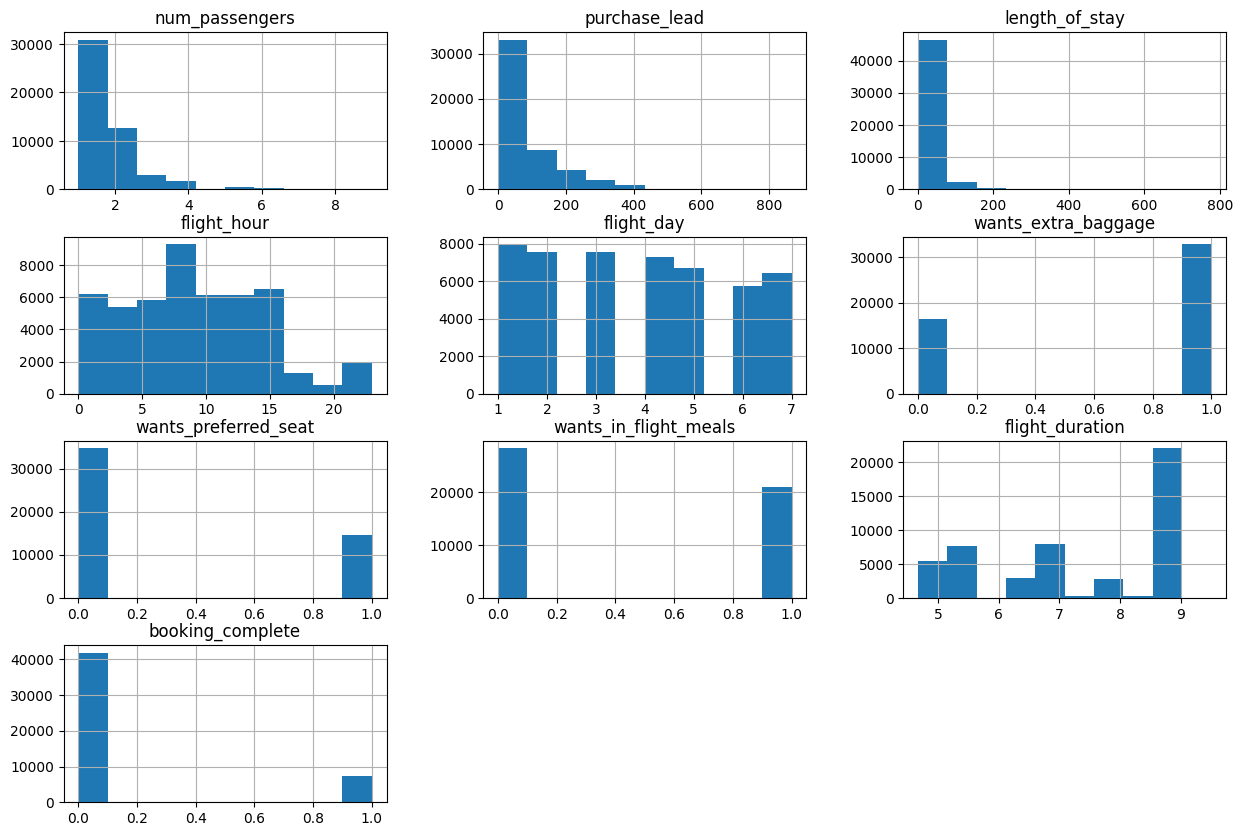

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
df.hist(figsize=(15,10))
plt.show()


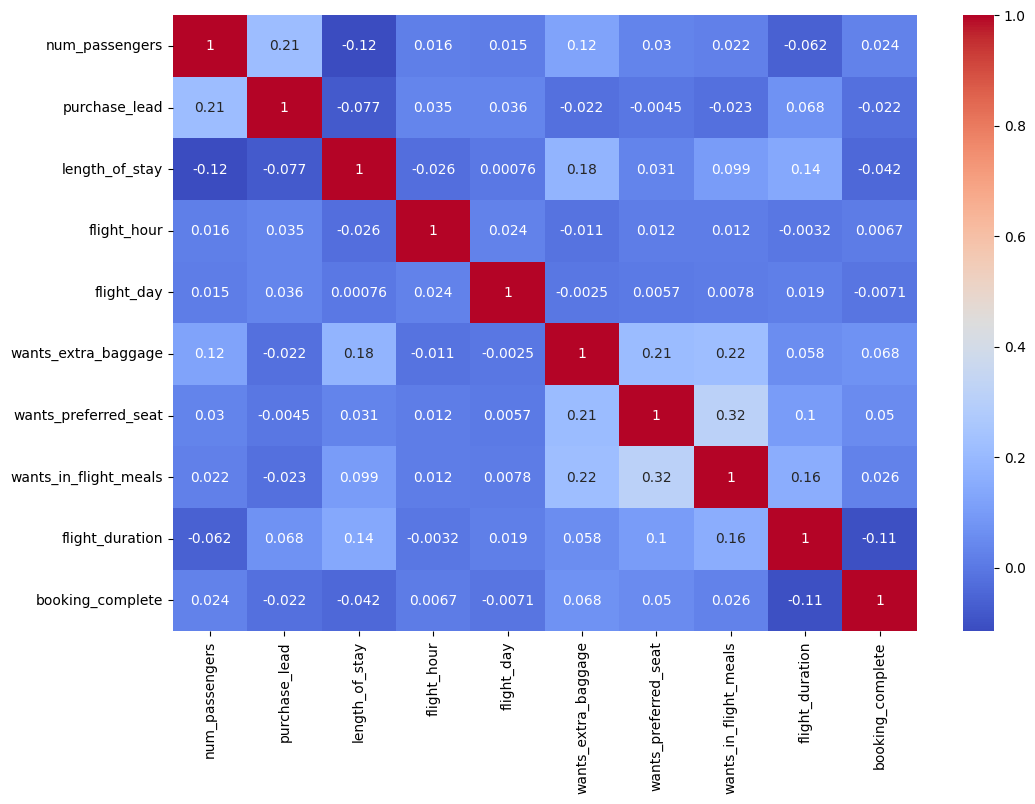

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


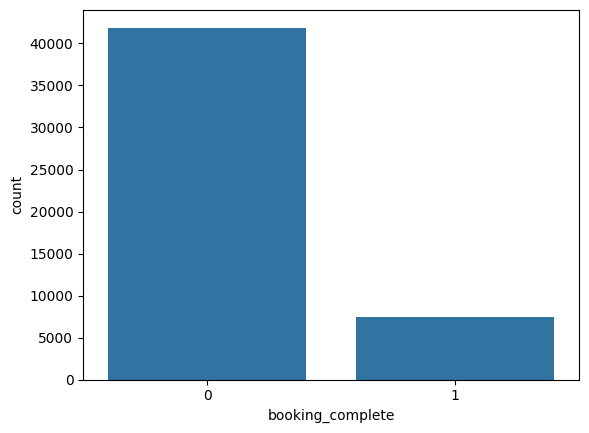

booking_complete
0    41890
1     7391
Name: count, dtype: int64


In [14]:
sns.countplot(x='booking_complete', data=df)
plt.show()

print(df['booking_complete'].value_counts())


In [17]:
df['is_weekend'] = df['flight_day'].apply(lambda x: 1 if x in [6,7] else 0)

In [18]:
df['long_stay'] = df['length_of_stay'].apply(lambda x: 1 if x > 7 else 0)

In [19]:
df['booking_urgency'] = pd.cut(
    df['purchase_lead'],
    bins=[0,7,30,90,500],
    labels=['Very_Close','Close','Medium','Early']
)

In [20]:
df = pd.get_dummies(df, drop_first=True)


In [21]:
X = df[['purchase_lead', 'length_of_stay', 'flight_hour']]

y = df['booking_complete']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

model.fit(X, y)


RandomForestClassifier(n_estimators=50, random_state=42)

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9303033377295323
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      8378
           1       0.89      0.61      0.73      1479

    accuracy                           0.93      9857
   macro avg       0.91      0.80      0.84      9857
weighted avg       0.93      0.93      0.92      9857



In [26]:
y_pred = model.predict(X_test)


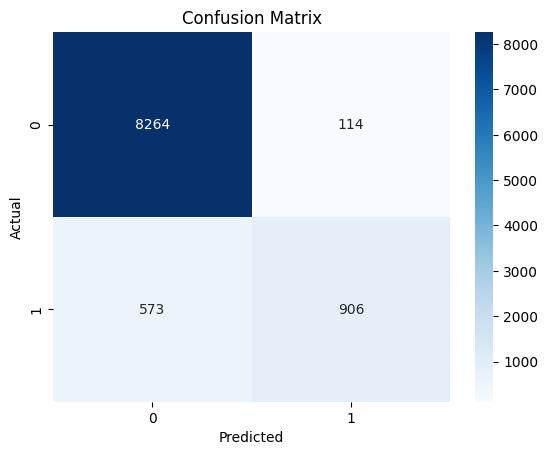

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [29]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

          Feature  Importance
0   purchase_lead    0.632822
1  length_of_stay    0.202406
2     flight_hour    0.164772


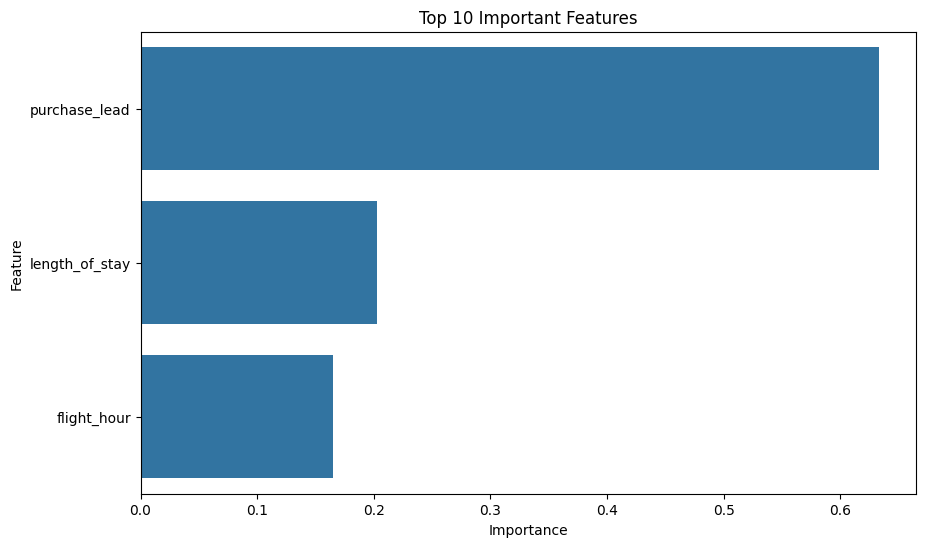

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [31]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())



Cross Validation Scores: [0.83899767 0.83390828 0.74736201 0.38676948 0.34263393]
Mean CV Accuracy: 0.6299342735863102


In [32]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 48.7 MB/s eta 0:00:00


In [37]:
import streamlit as st
import pickle
import pandas as pd

# Page configuration
st.set_page_config(
    page_title="Customer Booking Prediction",
    page_icon="✈️",
    layout="centered"
)

# Load trained model
model = pickle.load(open("model.pkl", "rb"))

# Title
st.title("✈️ Customer Booking Prediction System")

st.markdown("""
This application predicts whether a customer is likely to complete a booking.
""")

# Sidebar
st.sidebar.header("About Project")

st.sidebar.info("""
Machine Learning model built using Random Forest Classifier.

This project predicts customer booking completion behavior.
""")

# Input Section
st.subheader("Enter Customer Details")

purchase_lead = st.number_input(
    "Purchase Lead",
    min_value=0,
    max_value=500,
    value=30
)

length_of_stay = st.number_input(
    "Length of Stay",
    min_value=1,
    max_value=50,
    value=5
)

flight_hour = st.slider(
    "Flight Hour",
    0,
    23,
    12
)

# Predict Button
if st.button("Predict Booking"):

    input_data = pd.DataFrame({
        'purchase_lead': [purchase_lead],
        'length_of_stay': [length_of_stay],
        'flight_hour': [flight_hour]
    })

    prediction = model.predict(input_data)

    probability = model.predict_proba(input_data)[0][1]

    st.subheader("Prediction Result")

    if prediction[0] == 1:
        st.success("✅ Customer is likely to complete booking")
    else:
        st.error("❌ Customer is unlikely to complete booking")

    st.write(f"Prediction Confidence: {probability:.2%}")

    st.progress(int(probability * 100))

# Footer
st.markdown("---")
st.caption("Built with Streamlit and Scikit-Learn")

2026-05-28 11:18:44.103 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


UnpicklingError: invalid load key, 'x'.

In [35]:
import joblib

joblib.dump(model, 'model.pkl', compress=9)

['model.pkl']

In [36]:
import joblib

model = joblib.load("model.pkl")


In [39]:
import streamlit as st
import pickle
import pandas as pd

# Page configuration
st.set_page_config(
    page_title="Customer Booking Prediction",
    page_icon="✈️",
    layout="centered"
)

# Load trained model
model = pickle.load(open("model.pkl", "rb"))

# Title
st.title("✈️ Customer Booking Prediction System")

st.markdown("""
This application predicts whether a customer is likely to complete a booking.
""")

# Sidebar
st.sidebar.header("About Project")

st.sidebar.info("""
Machine Learning model built using Random Forest Classifier.

This project predicts customer booking completion behavior.
""")

# Input Section
st.subheader("Enter Customer Details")

purchase_lead = st.number_input(
    "Purchase Lead",
    min_value=0,
    max_value=500,
    value=30
)

length_of_stay = st.number_input(
    "Length of Stay",
    min_value=1,
    max_value=50,
    value=5
)

flight_hour = st.slider(
    "Flight Hour",
    0,
    23,
    12
)

# Predict Button
if st.button("Predict Booking"):

    input_data = pd.DataFrame({
        'purchase_lead': [purchase_lead],
        'length_of_stay': [length_of_stay],
        'flight_hour': [flight_hour]
    })

    prediction = model.predict(input_data)

    probability = model.predict_proba(input_data)[0][1]

    st.subheader("Prediction Result")

    if prediction[0] == 1:
        st.success("✅ Customer is likely to complete booking")
    else:
        st.error("❌ Customer is unlikely to complete booking")

    st.write(f"Prediction Confidence: {probability:.2%}")

    st.progress(int(probability * 100))

# Footer
st.markdown("---")
st.caption("Built with Streamlit and Scikit-Learn")

2026-05-28 11:20:06.548 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


UnpicklingError: invalid load key, 'x'.

In [40]:
import joblib

model = joblib.load("model.pkl")


In [41]:
model = joblib.load("model.pkl")


In [ ]:
import streamlit as st import pickle import pandas as pd # Page configuration st.set_page_config( page_title="Customer Booking Prediction", page_icon="✈️", layout="centered" ) # Load trained model model = pickle.load(open("model.pkl", "rb")) # Title st.title("✈️ Customer Booking Prediction System") st.markdown(""" This application predicts whether a customer is likely to complete a booking. """) # Sidebar st.sidebar.header("About Project") st.sidebar.info(""" Machine Learning model built using Random Forest Classifier. This project predicts customer booking completion behavior. """) # Input Section st.subheader("Enter Customer Details") purchase_lead = st.number_input( "Purchase Lead", min_value=0, max_value=500, value=30 ) length_of_stay = st.number_input( "Length of Stay", min_value=1, max_value=50, value=5 ) flight_hour = st.slider( "Flight Hour", 0, 23, 12 ) # Predict Button if st.button("Predict Booking"): input_data = pd.DataFrame({ 'purchase_lead': [purchase_lead], 'length_of_stay': [length_of_stay], 'flight_hour': [flight_hour] }) prediction = model.predict(input_data) probability = model.predict_proba(input_data)[0][1] st.subheader("Prediction Result") if prediction[0] == 1: st.success("✅ Customer is likely to complete booking") else: st.error("❌ Customer is unlikely to complete booking") st.write(f"Prediction Confidence: {probability:.2%}") st.progress(int(probability * 100)) # Footer st.markdown("---") st.caption("Built with Streamlit and Scikit-Learn")

In [43]:
import streamlit as st
import joblib
import pandas as pd

# ---------------------------------------------------
# PAGE CONFIGURATION
# ---------------------------------------------------

st.set_page_config(
    page_title="Flight Booking Predictor",
    page_icon="✈️",
    layout="centered"
)

# ---------------------------------------------------
# LOAD TRAINED MODEL
# ---------------------------------------------------

model = joblib.load("model.pkl")

# ---------------------------------------------------
# MAIN TITLE
# ---------------------------------------------------

st.title("✈️ Customer Booking Prediction System")

st.markdown("""
This application predicts whether a customer is likely to complete a flight booking using Machine Learning.
""")

# ---------------------------------------------------
# SIDEBAR
# ---------------------------------------------------

st.sidebar.header("About Project")

st.sidebar.info("""
Machine Learning model developed using Random Forest Classifier.

The model predicts customer booking completion behavior based on booking-related features.
""")

# ---------------------------------------------------
# INPUT SECTION
# ---------------------------------------------------

st.subheader("Enter Customer Details")

purchase_lead = st.number_input(
    "Purchase Lead (Days before flight booking)",
    min_value=0,
    max_value=500,
    value=30
)

length_of_stay = st.number_input(
    "Length of Stay (Days)",
    min_value=1,
    max_value=60,
    value=5
)

flight_hour = st.slider(
    "Flight Hour",
    0,
    23,
    12
)

# ---------------------------------------------------
# PREDICTION BUTTON
# ---------------------------------------------------

if st.button("Predict Booking"):

    # Create input dataframe
    input_data = pd.DataFrame({
        'purchase_lead': [purchase_lead],
        'length_of_stay': [length_of_stay],
        'flight_hour': [flight_hour]
    })

    # Prediction
    prediction = model.predict(input_data)

    # Prediction probability
    probability = model.predict_proba(input_data)[0][1]

    # ---------------------------------------------------
    # OUTPUT SECTION
    # ---------------------------------------------------

    st.subheader("Prediction Result")

    if prediction[0] == 1:
        st.success("✅ Customer is likely to complete booking")
    else:
        st.error("❌ Customer is unlikely to complete booking")

    # Confidence score
    st.write(f"Prediction Confidence: {probability:.2%}")

    # Progress bar
    st.progress(int(probability * 100))

# ---------------------------------------------------
# FOOTER
# ---------------------------------------------------

st.markdown("---")

st.caption("Built with Streamlit, Scikit-Learn, and Python")

2026-05-28 11:24:41.085 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 11:24:42.160 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 11:24:42.564 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-28 11:24:42.565 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 11:24:42.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 11:24:42.567 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 11:24:42.568 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

In [44]:
%%writefile requirements.txt
pandas
numpy
scikit-learn
matplotlib
seaborn
streamlit
joblib

Writing requirements.txt
